This is simulation for Paper : A MODEL-BASED APPROACH TO ACTIVE NOISE CANCELLATION USING
LOUDSPEAKER ARRAY

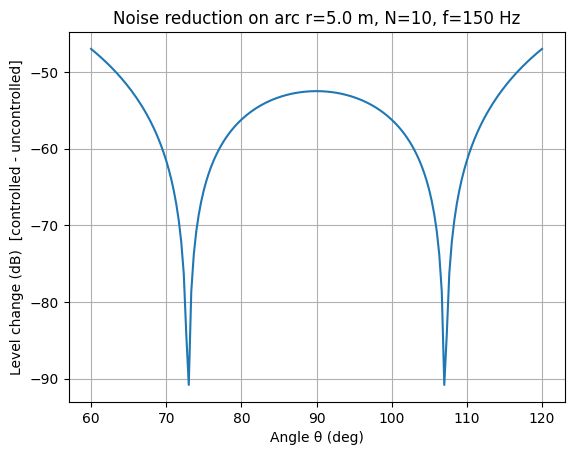

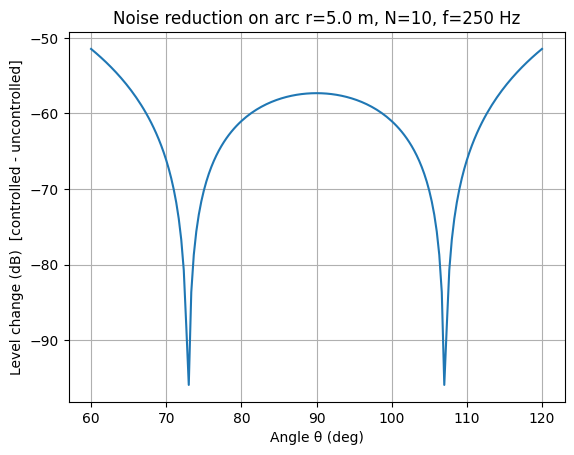

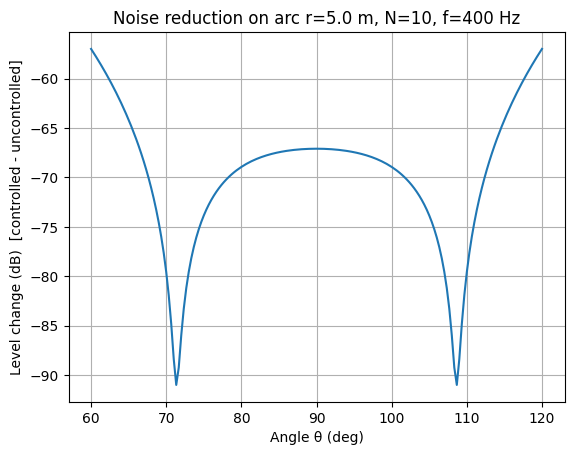

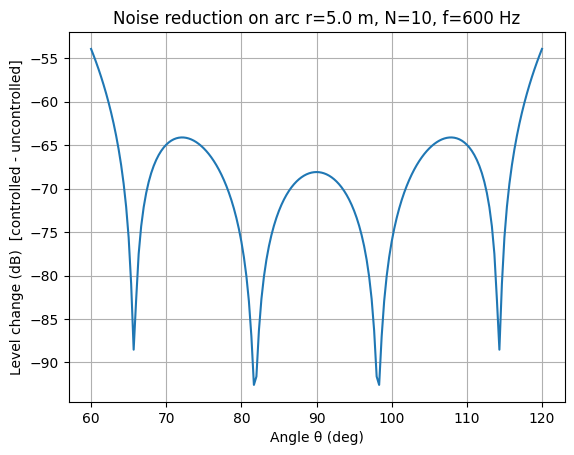

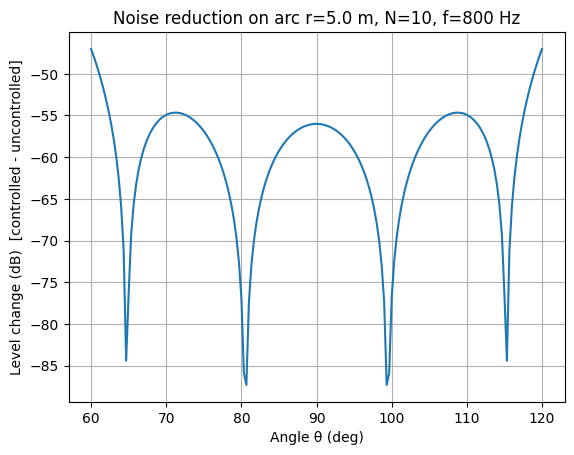

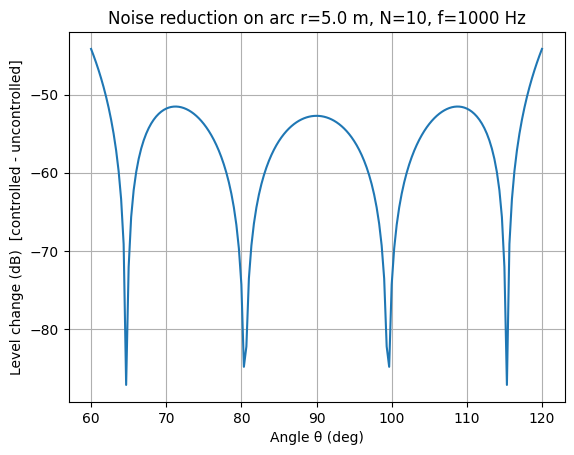

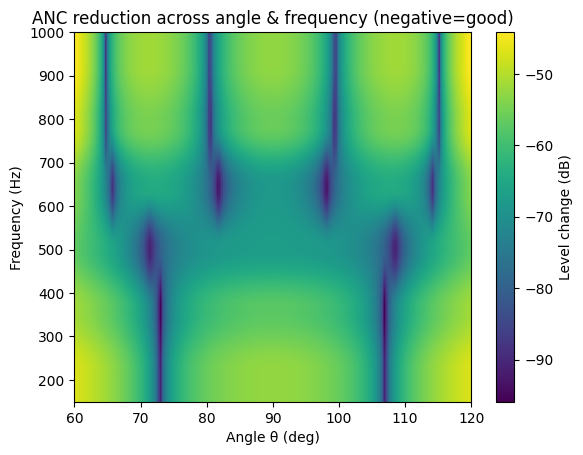

In [1]:
# Drone ANC "quiet-zone" simulation template
# -----------------------------------------------------------
# This script implements the model from:
#   "A model-based approach to active noise cancellation using loudspeaker array"
# It lets:
#   1) Define a primary source and an array of N secondary loudspeakers (monopoles).
#   2) Define a wedge-shaped quiet zone (angles [alpha, beta] at radius rqz).
#   3) For each frequency, solve least-squares for complex weights H_i(ω) that minimize
#      pressure in the quiet zone.
#   4) Evaluate residual pressure on an angular grid and plot results.
#
# You can adapt this to your drone geometry (arm lengths, speaker placements),
# and extend it to multiple error microphones and FxLMS later.
#
# NOTE: This is a *free-field* model using e^{-jkr}/r propagation and omnidirectional sources.
# -------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

c0 = 343.0  # speed of sound (m/s)

def k_from_f(f_hz, c=c0):
    return 2*np.pi*f_hz/c

def cart_from_polar(r, theta):
    return np.array([r*np.cos(theta), r*np.sin(theta)])

def distance(p, q):
    return np.linalg.norm(p - q, axis=0)

def build_primary_field(points_xy, f_hz, A=1.0, K=1.0, src_xy=np.array([0.0, 0.0])):
    """Primary field at given points from a monopole at src_xy."""
    k = k_from_f(f_hz)
    r = distance(points_xy, src_xy[:,None])
    return (A/K) * np.exp(-1j*k*r) / r

def build_secondary_matrix(points_xy, spk_xy, f_hz, K=1.0):
    """Return G (M x N): contribution at each field point from each speaker (monopole)."""
    k = k_from_f(f_hz)
    M = points_xy.shape[1]
    N = spk_xy.shape[1]
    G = np.zeros((M, N), dtype=complex)
    for i in range(N):
        r_i = distance(points_xy, spk_xy[:,i][:,None])
        G[:, i] = (1.0/K) * np.exp(-1j*k*r_i) / r_i
    return G

def solve_weights(points_xy, spk_xy, f_hz, lam=0.0):
    """Least-squares weights H that cancel primary in the quiet zone (Tikhonov-regularized)."""
    b = build_primary_field(points_xy, f_hz)  # M vector
    G = build_secondary_matrix(points_xy, spk_xy, f_hz)  # MxN
    # Solve: minimize || b + G H ||_2^2  => H* = -(G^H G + lam I)^{-1} G^H b
    GH_G = G.conj().T @ G
    if lam > 0:
        GH_G = GH_G + lam*np.eye(GH_G.shape[0])
    H = -np.linalg.solve(GH_G, G.conj().T @ b)
    return H, b, G

def evaluate_residual(points_xy, spk_xy, f_hz, H):
    """Residual complex pressure at points for given weights H."""
    b = build_primary_field(points_xy, f_hz)
    G = build_secondary_matrix(points_xy, spk_xy, f_hz)
    p = b + G @ H
    return p

def make_wedge_points(r, theta_min, theta_max, M):
    """Return grid points on an arc of radius r, evenly spaced in angle."""
    thetas = np.linspace(theta_min, theta_max, M)
    pts = cart_from_polar(r, thetas)
    return pts, thetas

def db(v, eps=1e-12):
    return 20*np.log10(np.maximum(np.abs(v), eps))

def demo_run(
    N=10,
    arm_span=0.4,  # total length across array (m)
    rqz=5.0,       # quiet-zone radius (m) where we evaluate on an arc
    th_min=np.deg2rad(60), th_max=np.deg2rad(120), M=181,
    freqs=[150, 250, 400, 600, 800, 1000],
    lam=1e-3
):
    # Speaker coordinates: equally spaced on x-axis centered at origin
    x_positions = np.linspace(-arm_span/2, arm_span/2, N)
    spk_xy = np.vstack([x_positions, np.zeros_like(x_positions)])  # 2xN

    # Field points on arc
    pts, thetas = make_wedge_points(rqz, th_min, th_max, M)

    results = {}
    for f in freqs:
        H, b, G = solve_weights(pts, spk_xy, f, lam=lam)
        pres0 = b                     # primary only
        presC = pres0 + G @ H         # controlled field
        nr_db = db(presC) - db(pres0) # negative values mean reduction
        results[f] = dict(H=H, pres0=pres0, presC=presC, nr_db=nr_db)

        # Plot reduction vs angle
        plt.figure()
        plt.plot(np.rad2deg(thetas), nr_db)
        plt.xlabel('Angle θ (deg)')
        plt.ylabel('Level change (dB)  [controlled - uncontrolled]')
        plt.title(f'Noise reduction on arc r={rqz} m, N={N}, f={f} Hz')
        plt.grid(True)
        plt.show()

    # Heatmap across freq & angle
    F = len(freqs)
    NR = np.zeros((F, M))
    for i, f in enumerate(freqs):
        NR[i,:] = results[f]['nr_db']
    plt.figure()
    plt.imshow(NR, aspect='auto', origin='lower',
               extent=[np.rad2deg(th_min), np.rad2deg(th_max), freqs[0], freqs[-1]])
    plt.colorbar(label='Level change (dB)')
    plt.xlabel('Angle θ (deg)')
    plt.ylabel('Frequency (Hz)')
    plt.title('ANC reduction across angle & frequency (negative=good)')
    plt.show()

    return dict(spk_xy=spk_xy, thetas=thetas, results=results)

# Run the demo with defaults (10 speakers across 0.4 m; wedge 60–120 deg)
out = demo_run()
